In [1]:
import pandas as pd
pizdf= pd.read_csv("pizza_sales.csv")
print(pizdf.head(2))
print(pizdf.dtypes)

   pizza_id  order_id  pizza_name_id  quantity  order_date order_time  \
0         1         1     hawaiian_m         1  01-01-2015   11:38:36   
1         2         2  classic_dlx_m         1  01-01-2015   11:57:40   

   unit_price  total_price pizza_size pizza_category  \
0       13.25        13.25          M        Classic   
1       16.00        16.00          M        Classic   

                                   pizza_ingredients                pizza_name  
0           Sliced Ham, Pineapple, Mozzarella Cheese        The Hawaiian Pizza  
1  Pepperoni, Mushrooms, Red Onions, Red Peppers,...  The Classic Deluxe Pizza  
pizza_id               int64
order_id               int64
pizza_name_id            str
quantity               int64
order_date               str
order_time               str
unit_price           float64
total_price          float64
pizza_size               str
pizza_category           str
pizza_ingredients        str
pizza_name               str
dtype: object


In [2]:
#pizdf['order_date']=pd.to_datetime(pizdf['order_date'])
pizdf['order_date'] = pd.to_datetime(pizdf['order_date'], dayfirst=True, errors='coerce')
print(pizdf.dtypes)

pizza_id                      int64
order_id                      int64
pizza_name_id                   str
quantity                      int64
order_date           datetime64[us]
order_time                      str
unit_price                  float64
total_price                 float64
pizza_size                      str
pizza_category                  str
pizza_ingredients               str
pizza_name                      str
dtype: object


In [3]:
print(pizdf['order_date'].unique())

<DatetimeArray>
['2015-01-01 00:00:00', '2015-01-02 00:00:00', '2015-01-03 00:00:00',
 '2015-01-04 00:00:00', '2015-01-05 00:00:00', '2015-01-06 00:00:00',
 '2015-01-07 00:00:00', '2015-01-08 00:00:00', '2015-01-09 00:00:00',
 '2015-01-10 00:00:00',
 ...
 '2015-12-21 00:00:00', '2015-12-22 00:00:00', '2015-12-23 00:00:00',
 '2015-12-24 00:00:00', '2015-12-26 00:00:00', '2015-12-27 00:00:00',
 '2015-12-28 00:00:00', '2015-12-29 00:00:00', '2015-12-30 00:00:00',
 '2015-12-31 00:00:00']
Length: 358, dtype: datetime64[us]


In [4]:
pizdf['year'] = pizdf['order_date'].dt.year
pizdf['month'] = pizdf['order_date'].dt.month
pizdf['day'] = pizdf['order_date'].dt.day
print(pizdf.head(5))

   pizza_id  order_id  pizza_name_id  quantity order_date order_time  \
0         1         1     hawaiian_m         1 2015-01-01   11:38:36   
1         2         2  classic_dlx_m         1 2015-01-01   11:57:40   
2         3         2  five_cheese_l         1 2015-01-01   11:57:40   
3         4         2    ital_supr_l         1 2015-01-01   11:57:40   
4         5         2     mexicana_m         1 2015-01-01   11:57:40   

   unit_price  total_price pizza_size pizza_category  \
0       13.25        13.25          M        Classic   
1       16.00        16.00          M        Classic   
2       18.50        18.50          L         Veggie   
3       20.75        20.75          L        Supreme   
4       16.00        16.00          M         Veggie   

                                   pizza_ingredients  \
0           Sliced Ham, Pineapple, Mozzarella Cheese   
1  Pepperoni, Mushrooms, Red Onions, Red Peppers,...   
2  Mozzarella Cheese, Provolone Cheese, Smoked Go...   
3  Cal

In [5]:
pizdf['order_time'] = pd.to_datetime(pizdf['order_time'], format='%H:%M:%S', errors='coerce')

In [6]:
pizdf['hour'] = pizdf['order_time'].dt.hour
pizdf['minute'] = pizdf['order_time'].dt.minute
pizdf['second'] = pizdf['order_time'].dt.second
print(pizdf.head(5))

   pizza_id  order_id  pizza_name_id  quantity order_date          order_time  \
0         1         1     hawaiian_m         1 2015-01-01 1900-01-01 11:38:36   
1         2         2  classic_dlx_m         1 2015-01-01 1900-01-01 11:57:40   
2         3         2  five_cheese_l         1 2015-01-01 1900-01-01 11:57:40   
3         4         2    ital_supr_l         1 2015-01-01 1900-01-01 11:57:40   
4         5         2     mexicana_m         1 2015-01-01 1900-01-01 11:57:40   

   unit_price  total_price pizza_size pizza_category  \
0       13.25        13.25          M        Classic   
1       16.00        16.00          M        Classic   
2       18.50        18.50          L         Veggie   
3       20.75        20.75          L        Supreme   
4       16.00        16.00          M         Veggie   

                                   pizza_ingredients  \
0           Sliced Ham, Pineapple, Mozzarella Cheese   
1  Pepperoni, Mushrooms, Red Onions, Red Peppers,...   
2  Mozza

year
2015    817860.05
Name: total_price, dtype: float64


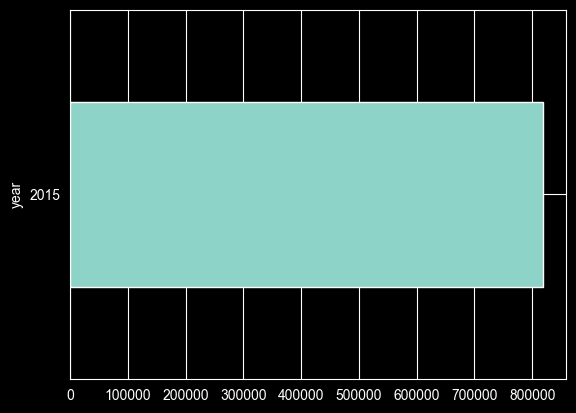

In [7]:
import matplotlib.pyplot as plt
yearwisesales=pizdf.groupby('year')['total_price'].sum()
print(yearwisesales)
yearwisesales.plot(kind='barh')
plt.show()

month
1     69793.30
2     65159.60
3     70397.10
4     68736.80
5     71402.75
6     68230.20
7     72557.90
8     68278.25
9     64180.05
10    64027.60
11    70395.35
12    64701.15
Name: total_price, dtype: float64


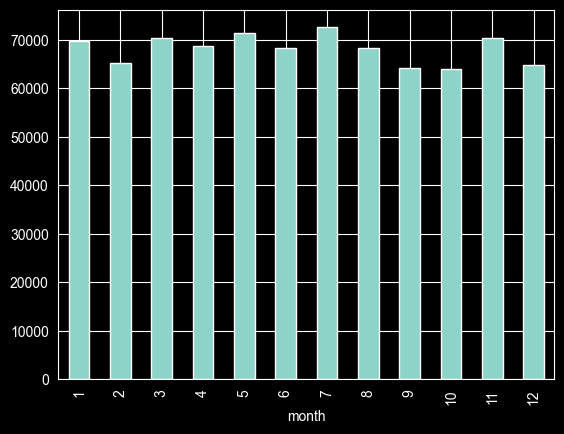

In [8]:
monthwisesales=pizdf.groupby('month')['total_price'].sum()
print(monthwisesales)
monthwisesales.plot(kind='bar')
plt.show()

day
1     29608.55
2     27495.40
3     27993.15
4     29675.65
5     23988.40
6     28097.45
7     27636.40
8     27976.90
9     27963.90
10    26967.95
11    27756.20
12    24169.85
13    27665.10
14    27727.25
15    30588.90
16    26890.35
17    27969.25
18    26913.70
19    24755.70
20    27811.20
21    26028.70
22    25004.80
23    27137.05
24    26098.60
25    20875.80
26    25247.35
27    29655.95
28    24154.85
29    23045.40
30    24230.60
31    16729.70
Name: total_price, dtype: float64


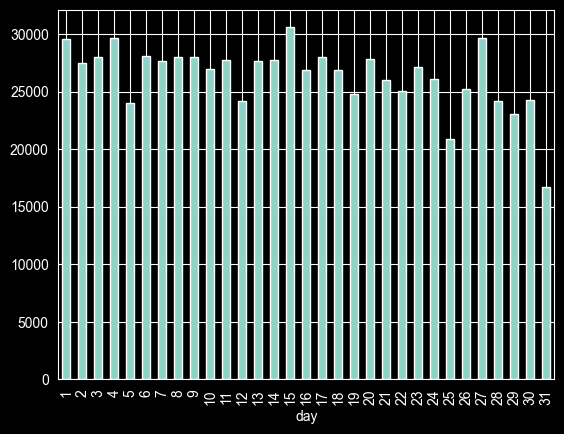

In [9]:
daywisesales=pizdf.groupby('day')['total_price'].sum()
print(daywisesales)
daywisesales.plot(kind='bar')
plt.show()

month  day
1      1      2713.85
       2      2731.90
       3      2662.40
       4      1755.45
       5      2065.95
       6      2428.95
       7      2202.20
       8      2838.35
       9      2127.35
       10     2463.95
       11     1872.30
       12     1919.05
       13     2049.60
       14     2527.40
       15     1984.80
       16     2594.15
       17     2064.10
       18     1976.85
       19     2387.15
       20     2397.90
       21     2040.55
       22     2496.70
       23     2423.70
       24     2289.25
       25     1617.55
       26     1884.40
       27     2528.05
       28     2016.00
       29     2045.30
       30     2270.30
       31     2417.85
2      1      3189.20
       2      2328.60
       3      2614.80
       4      2233.90
       5      2215.80
       6      2509.95
       7      2237.65
       8      2035.00
       9      2195.35
       10     2056.50
       11     2460.00
       12     2158.80
       13     2754.50
       14     2319.15

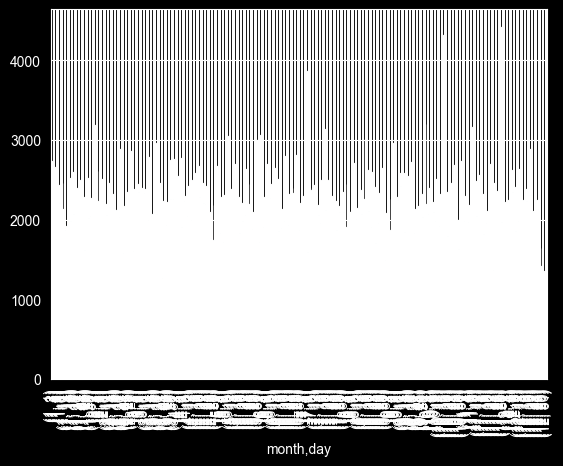

In [10]:
monthdaywisesales=pizdf.groupby(['month','day'])['total_price'].sum()
print(monthdaywisesales.to_string())
monthdaywisesales.plot(kind='bar')
plt.show()

hour
9         83.00
10       303.65
11     44935.80
12    111877.90
13    106065.70
14     59201.40
15     52992.30
16     70055.40
17     86237.45
18     89296.85
19     72628.90
20     58215.40
21     42029.80
22     22815.15
23      1121.35
Name: total_price, dtype: float64


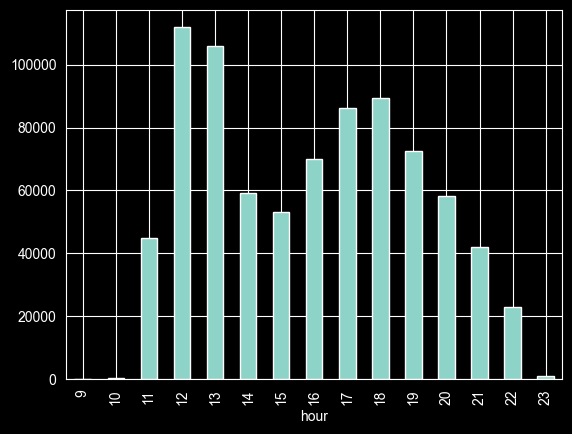

In [11]:
hourwisesales=pizdf.groupby('hour')['total_price'].sum()
print(hourwisesales)
hourwisesales.plot(kind='bar')
plt.show()

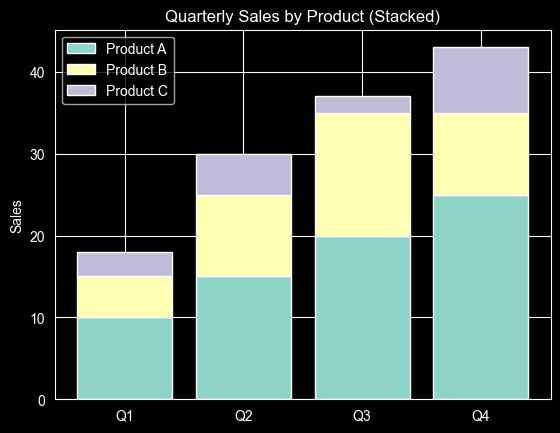

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_A = [10, 15, 20, 25]
product_B = [5, 10, 15, 10]
product_C = [3, 5, 2, 8]

x = np.arange(len(categories))
print()

# Plot bars
plt.bar(x, product_A, label='Product A')
plt.bar(x, product_B, bottom=product_A, label='Product B')
bottom_AB = np.array(product_A) + np.array(product_B)
# print(bottom_AB)
plt.bar(x, product_C, bottom=bottom_AB, label='Product C')

# Add labels and legend
plt.xticks(x, categories)
plt.ylabel('Sales')
plt.title('Quarterly Sales by Product (Stacked)')
plt.legend()

plt.show()

hour  pizza_category
9     Classic              2
      Supreme              1
      Veggie               1
10    Chicken              7
      Classic              6
      Supreme              3
      Veggie               2
11    Chicken            595
      Classic            860
      Supreme            676
      Veggie             597
12    Chicken           1488
      Classic           2039
      Supreme           1612
      Veggie            1637
13    Chicken           1432
      Classic           1931
      Supreme           1549
      Veggie            1501
14    Chicken            804
      Classic           1098
      Supreme            861
      Veggie             850
15    Chicken            715
      Classic            929
      Supreme            807
      Veggie             765
16    Chicken            938
      Classic           1292
      Supreme           1022
      Veggie             987
17    Chicken           1173
      Classic           1608
      Supreme         

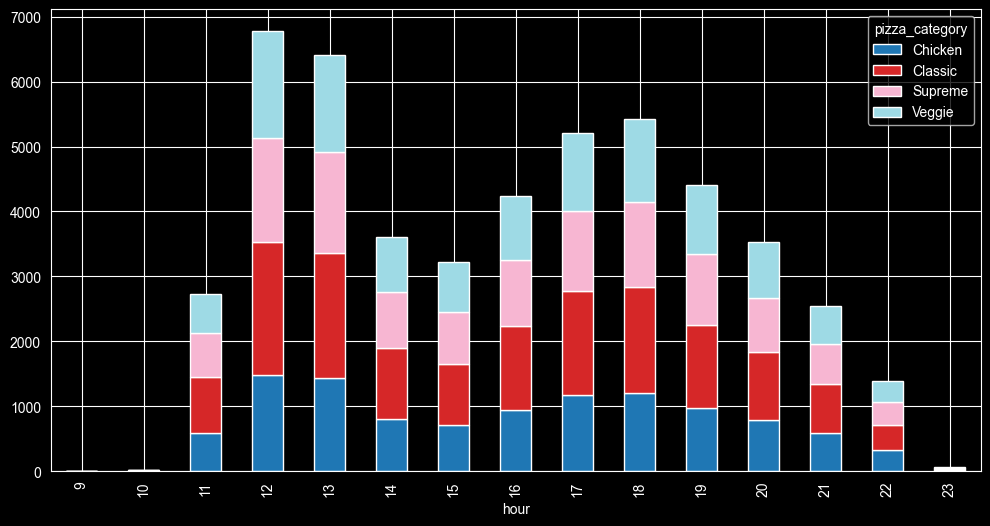

In [13]:
# Group by hour and pizza_category, sum the quantities
dubgrouped = pizdf.groupby(['hour', 'pizza_category'])['quantity'].sum()
print(dubgrouped)
grouped = pizdf.groupby(['hour', 'pizza_category'])['quantity'].sum().unstack(fill_value=0)
print(grouped)

# Plot
ax = grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')

       Category Sub-Category   Region       Ship Mode       Sales
0     Furniture    Bookcases  Central     First Class   5418.6764
1     Furniture    Bookcases  Central    Second Class   6365.5864
2     Furniture    Bookcases  Central  Standard Class  12372.9140
3     Furniture    Bookcases     East     First Class   4820.8720
4     Furniture    Bookcases     East        Same Day   1294.2720
..          ...          ...      ...             ...         ...
264  Technology       Phones    South  Standard Class  34499.3420
265  Technology       Phones     West     First Class  18327.7600
266  Technology       Phones     West        Same Day   4212.4960
267  Technology       Phones     West    Second Class  16237.7360
268  Technology       Phones     West  Standard Class  59906.3600

[269 rows x 5 columns]


Text(0.5, 0.98, 'Sales Distribution by Category, Sub-Category, Region, and Ship Mode')

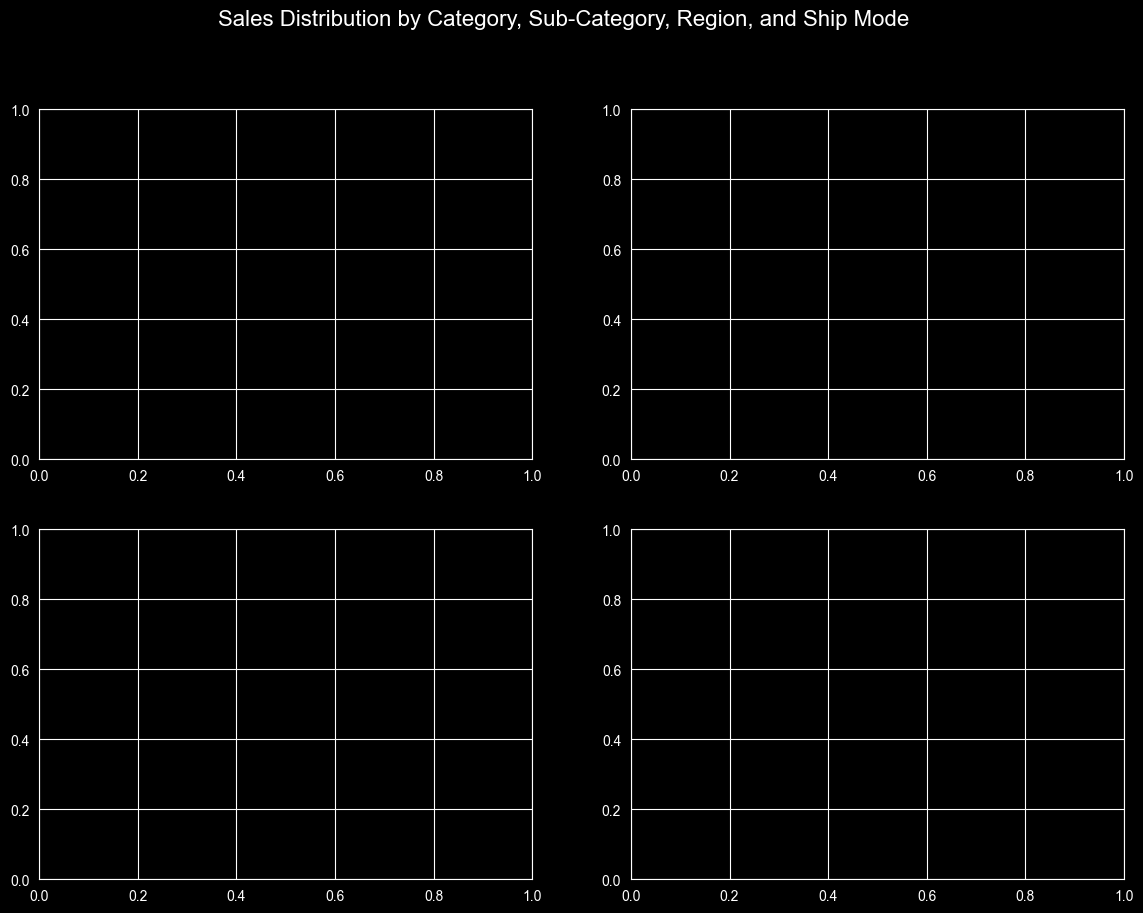

In [14]:
import seaborn as sns
x= pd.read_csv('samplesuperstore.csv')
grouped=x.groupby(['Category','Sub-Category','Region','Ship Mode'])['Sales'].sum().reset_index()
print(grouped)
grouped.to_csv('mydata.csv')

# Set up the figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Distribution by Category, Sub-Category, Region, and Ship Mode', fontsize=16)

In [54]:
# Subplot 1: Sales by Category
cat_sales = grouped.groupby('Category')['Sales'].sum().reset_index()
print(cat_sales)
sns.barplot(x='Category', y='Sales', data=cat_sales, ax=axs[0, 0],color='seagreen')
axs[0, 0].set_title('Sales by Category')

# Subplot 2: Sales by Sub-Category
subcat_sales = grouped.groupby('Sub-Category')['Sales'].sum().reset_index()
sns.barplot(x='Sales', y='Sub-Category', data=subcat_sales, ax=axs[0, 1],color='steelblue')
axs[0, 1].set_title('Sales by Sub-Category')

# Subplot 3: Sales by Region
region_sales = grouped.groupby('Region')['Sales'].sum().reset_index()
sns.barplot(x='Region', y='Sales', data=region_sales, ax=axs[1, 0], color='darkorange')
axs[1, 0].set_title('Sales by Region')

# Subplot 4: Sales by Ship Mode
ship_sales = grouped.groupby('Ship Mode')['Sales'].sum().reset_index()
sns.barplot(x='Sales', y='Ship Mode', data=ship_sales, ax=axs[1, 1],color='mediumpurple')
axs[1, 1].set_title('Sales by Ship Mode')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

          Category        Sales
0        Furniture  741999.7953
1  Office Supplies  719047.0320
2       Technology  836154.0330


<Figure size 640x480 with 0 Axes>

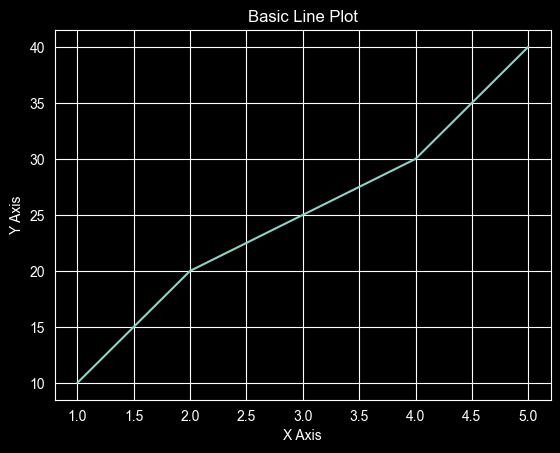

In [16]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [10, 20, 25, 30, 40]

plt.plot(x, y)
plt.title("Basic Line Plot")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.show()

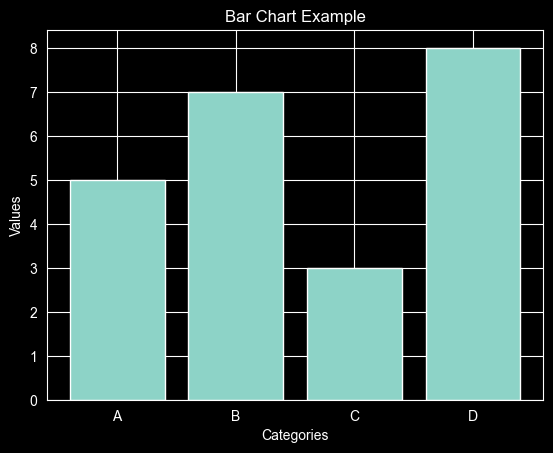

In [17]:
import matplotlib.pyplot as plt

categories = ['A', 'B', 'C', 'D']
values = [5, 7, 3, 8]

plt.bar(categories, values)
plt.title("Bar Chart Example")
plt.xlabel("Categories")
plt.ylabel("Values")
plt.show()

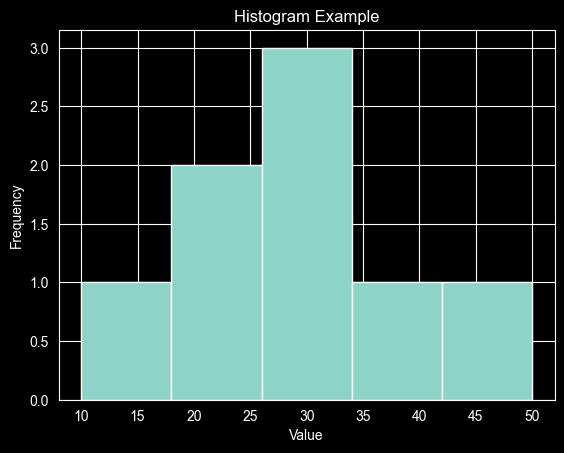

In [38]:
import matplotlib.pyplot as plt

data = [10, 20, 20, 30, 30, 30, 40, 50]

plt.hist(data, bins=5)
plt.title("Histogram Example")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

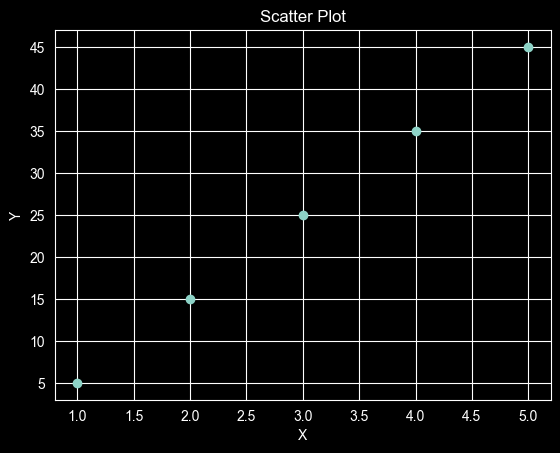

In [19]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [5, 15, 25, 35, 45]

plt.scatter(x, y)
plt.title("Scatter Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

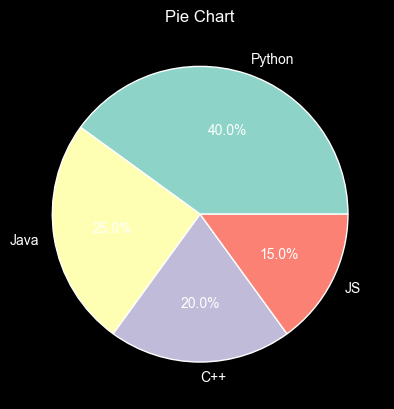

In [39]:
import matplotlib.pyplot as plt

labels = ['Python', 'Java', 'C++', 'JS']
sizes = [40, 25, 20, 15]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Pie Chart")
plt.show()

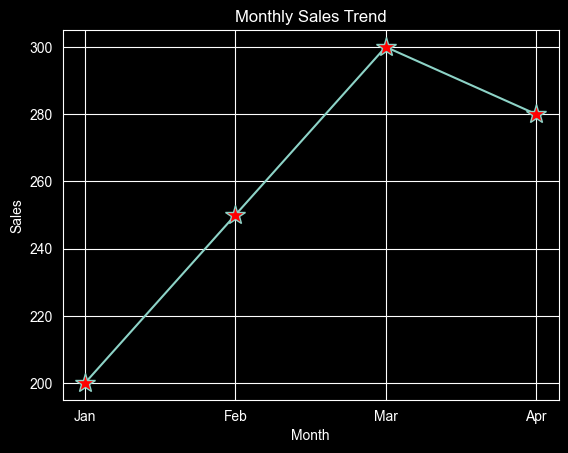

In [48]:
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr']
sales = [200, 250, 300, 280]

plt.plot(months, sales, marker='*', ms= 15, mfc = 'red')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

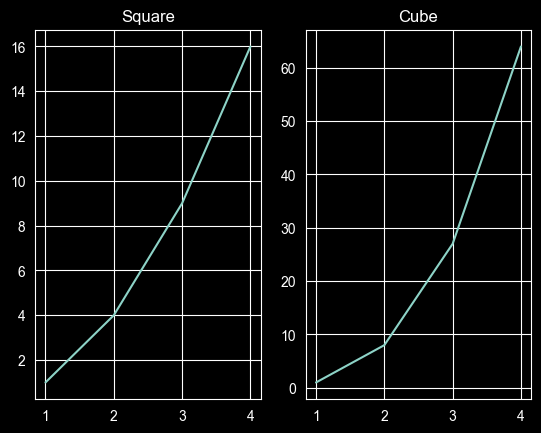

In [22]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]

plt.subplot(1, 2, 1)
plt.plot(x, [i**2 for i in x])
plt.title("Square")

plt.subplot(1, 2, 2)
plt.plot(x, [i**3 for i in x])
plt.title("Cube")

plt.show()

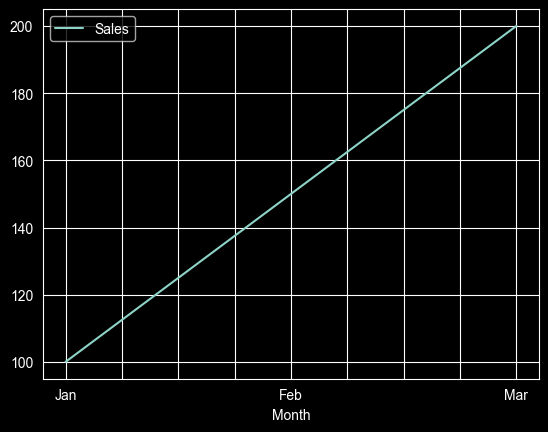

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar'],
    'Sales': [100, 150, 200]
})

df.plot(x='Month', y='Sales', kind='line')
plt.show()

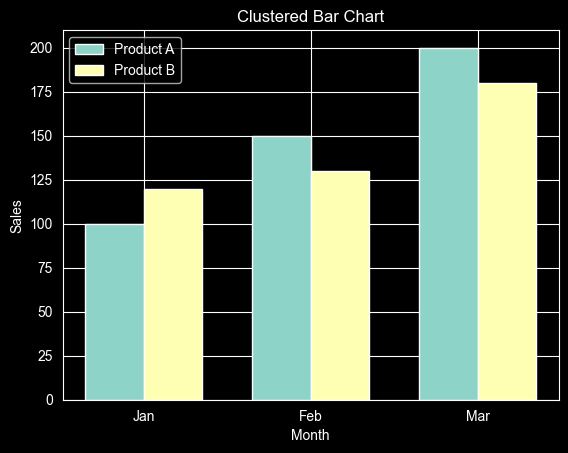

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Sample Data
categories = ['Jan', 'Feb', 'Mar']
sales_A = [100, 150, 200]
sales_B = [120, 130, 180]

x = np.arange(len(categories))  # positions
width = 0.35

plt.bar(x - width/2, sales_A, width, label='Product A')
plt.bar(x + width/2, sales_B, width, label='Product B')

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Clustered Bar Chart')
plt.xticks(x, categories)
plt.legend()

plt.show()

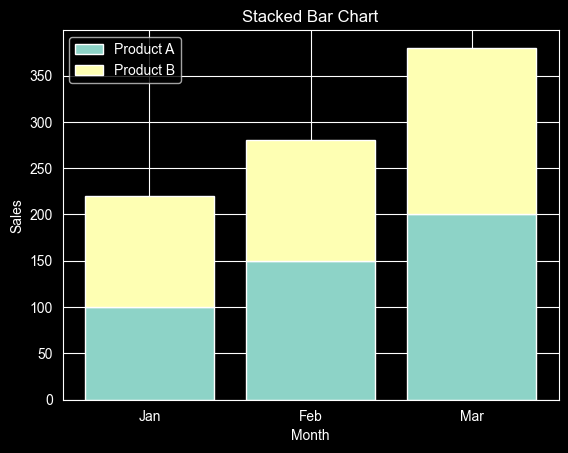

In [26]:
import matplotlib.pyplot as plt

categories = ['Jan', 'Feb', 'Mar']
sales_A = [100, 150, 200]
sales_B = [120, 130, 180]

plt.bar(categories, sales_A, label='Product A')
plt.bar(categories, sales_B, bottom=sales_A, label='Product B')

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Stacked Bar Chart')
plt.legend()

plt.show()

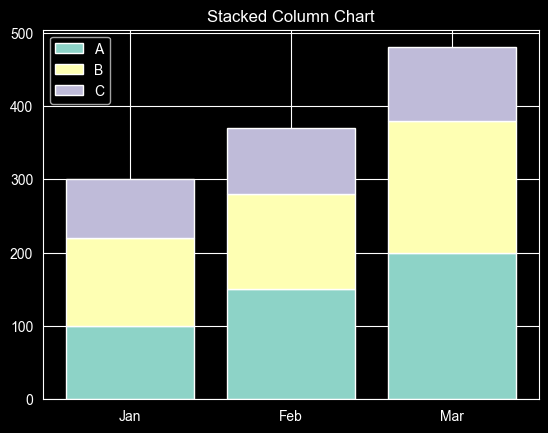

In [27]:
import numpy as np
import matplotlib.pyplot as plt

categories = ['Jan', 'Feb', 'Mar']
sales_A = np.array([100, 150, 200])
sales_B = np.array([120, 130, 180])
sales_C = np.array([80, 90, 100])

plt.bar(categories, sales_A, label='A')
plt.bar(categories, sales_B, bottom=sales_A, label='B')
plt.bar(categories, sales_C, bottom=sales_A + sales_B, label='C')

plt.title("Stacked Column Chart")
plt.legend()

plt.show()

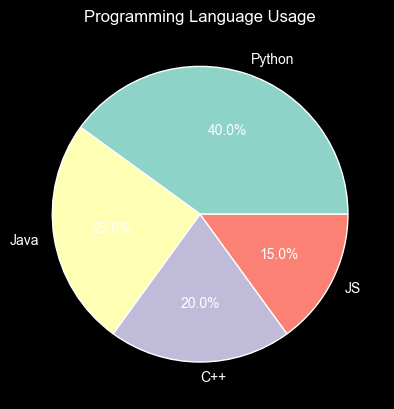

In [28]:
import matplotlib.pyplot as plt

labels = ['Python', 'Java', 'C++', 'JS']
sizes = [40, 25, 20, 15]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Programming Language Usage")
plt.show()

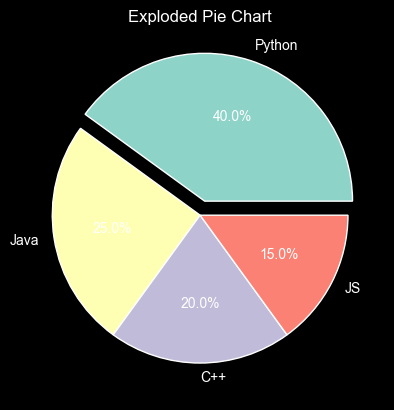

In [29]:
explode = [0.1, 0, 0, 0]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', explode=explode)
plt.title("Exploded Pie Chart")
plt.show()

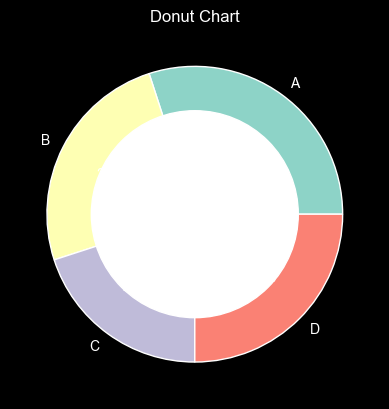

In [30]:
import matplotlib.pyplot as plt

labels = ['A', 'B', 'C', 'D']
sizes = [30, 25, 20, 25]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# Draw circle for donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Donut Chart")
plt.show()

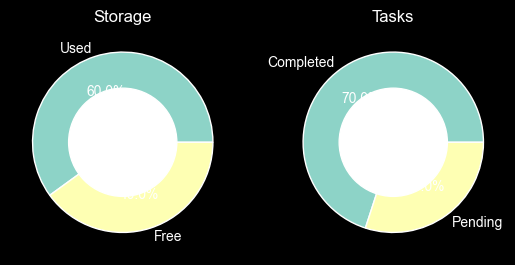

In [31]:
fig, ax = plt.subplots(1, 2)

# Chart 1
ax[0].pie([60, 40], labels=['Used', 'Free'], autopct='%1.1f%%')
ax[0].add_artist(plt.Circle((0,0), 0.6, color='white'))
ax[0].set_title("Storage")

# Chart 2
ax[1].pie([70, 30], labels=['Completed', 'Pending'], autopct='%1.1f%%')
ax[1].add_artist(plt.Circle((0,0), 0.6, color='white'))
ax[1].set_title("Tasks")

plt.show()

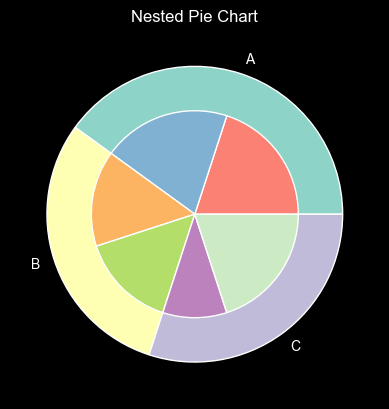

In [32]:
import matplotlib.pyplot as plt

# Outer ring
outer = [40, 30, 30]
# Inner ring
inner = [20, 20, 15, 15, 10, 20]

fig, ax = plt.subplots()

ax.pie(outer, radius=1, labels=['A','B','C'])
ax.pie(inner, radius=0.7)

plt.title("Nested Pie Chart")
plt.show()

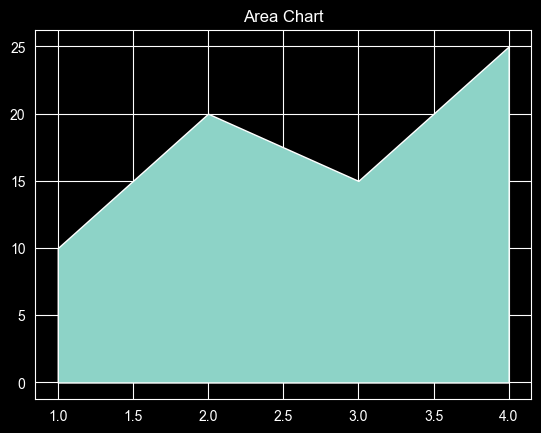

In [33]:
x = [1, 2, 3, 4]
y = [10, 20, 15, 25]

plt.fill_between(x, y)
plt.title("Area Chart")
plt.show()

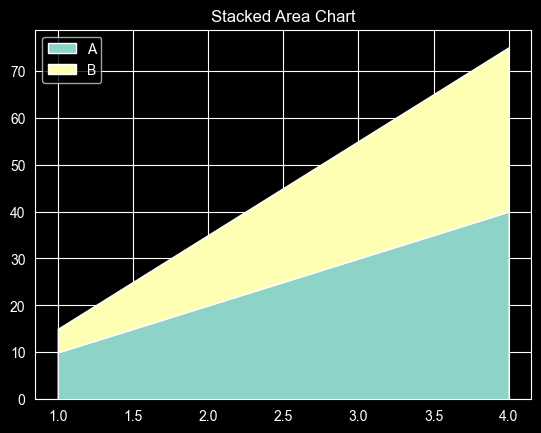

In [34]:
import numpy as np

x = [1, 2, 3, 4]
y1 = [10, 20, 30, 40]
y2 = [5, 15, 25, 35]

plt.stackplot(x, y1, y2, labels=['A', 'B'])
plt.legend()
plt.title("Stacked Area Chart")
plt.show()